# Vanilla RNN (SimpleRNN) — Sequence Modeling Types on Hourly Energy Data

This notebook builds **five classic RNN input/output typologies** — one-to-one,
many-to-one, one-to-many, many-to-many (synced), and many-to-many (encoder-decoder /
seq2seq) — all using **`tf.keras.layers.SimpleRNN`** as the recurrent
cell, via the Keras **Sequential API**. Every architecture is trained on the same
hourly Spanish electricity dataset (load, generation mix, price), so the only thing
that changes between sections is the *shape* of the supervised learning problem, not
the data or the cell type.

Each model trains for **100 epochs** and is drawn as a layer diagram before training
(`show_model_diagram`). Every `Sequential([...])` block also includes a **commented-out
second SimpleRNN layer** with a one-line note on what to flip — uncomment it
to go from a single-layer to a stacked (deep) recurrent network for that architecture.

## 1. The Vanilla RNN Cell


$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

A single hidden state $h_t$ is recomputed at every timestep from the current input $x_t$
and the *previous* hidden state $h_{t-1}$, squashed through $\tanh$. There is no
separate "memory cell" and no gating — the same weight matrices $W_{xh}, W_{hh}$ are
reused (shared) at every timestep, which is what makes this a *recurrent* network
rather than one feedforward layer per timestep.

**Known weakness:** because $h_{t-1}$ is repeatedly multiplied by $W_{hh}$ and passed
through $\tanh$, gradients during backpropagation-through-time tend to either vanish
or explode over long sequences — this is the textbook motivation for LSTM and GRU,
which you'll build in the companion notebooks.


### What you'll build

1. Load & clean the hourly energy dataset (with an offline synthetic fallback)
2. Chronological train/val/test split + scaling
3. Windowing utilities shared by all five architectures
4. **One-to-one** — single step in, single step out
5. **Many-to-one** — a window of history, one prediction
6. **One-to-many** — one snapshot, a generated forecast sequence
7. **Many-to-many (synced)** — a window in, one aligned prediction per step
8. **Many-to-many (seq2seq)** — a window of history, a differently-sized future window
9. Side-by-side comparison of parameter counts and validation performance


In [74]:
# ============================================================
# Name: Loretta Cruz
# BIOINFORMATICS
# ASSIGNMENT / QUIZ – RNN
# ============================================================

## 1b. Setup and Imports

Model architecture diagrams later in this notebook (`show_model_diagram`) need the `pydot` package and the Graphviz `dot` executable. If they're missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
# Debian/Ubuntu:
sudo apt-get install graphviz
# macOS:
brew install graphviz
```

In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.15 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:11:32) [Clang 20.1.8 ]

Python executable:
/opt/anaconda3/envs/rnn_assignment/bin/python


In [2]:
import tensorflow as tf

print("TensorFlow version:")
print(tf.__version__)

TensorFlow version:
2.21.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100


## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

The dataset contains ~4 years (2015–2018) of hourly Spanish electricity data in
`energy_dataset.csv`: total load, generation by source (solar, wind, gas, nuclear, ...),
day-ahead price forecasts, and actual settled prices.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated):
   ```bash
   pip install kagglehub
   ```

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so every
cell in this notebook still runs end-to-end without the real file. Swap in the real
CSV at any time — no other code needs to change, since every downstream cell only
depends on `FEATURE_COLS` / `TARGET_COL` existing in `df`.


In [4]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) "
              "so the rest of the notebook still runs end-to-end.")
        print("[info] See section 2 above for instructions on installing the real dataset.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

[info] Could not load the real Kaggle dataset (ModuleNotFoundError: No module named 'kagglehub').
[info] Falling back to a synthetic energy-like dataset (see DATA_LOADER_CODE) so the rest of the notebook still runs end-to-end.
[info] See section 2 above for instructions on installing the real dataset.
(3000, 5)


,total load actual,generation solar,generation wind onshore,generation fossil gas,price actual
time,,,,,
2018-01-01 00:00:00,26121.886832,187.353405,4635.070036,4584.255276,44.270897
2018-01-01 01:00:00,26619.500704,103.153828,4562.198944,4264.948320,47.950673
2018-01-01 02:00:00,28300.616808,294.919121,5206.577410,4379.785560,43.654361
2018-01-01 03:00:00,29205.307501,0.000000,5145.621944,4112.532146,45.508473
2018-01-01 04:00:00,28684.560185,0.000000,3082.747523,5431.236878,56.400750


In [5]:
# Keep only the columns this notebook uses, make the index a clean hourly
# DatetimeIndex, and fill any gaps (the real Kaggle file has a handful of
# missing hours/values).
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 3000   Range: 2018-01-01 00:00:00 -> 2018-05-05 23:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,3000.0,26012.466411,2975.575803,20148.011389,23364.934962,25988.117226,28674.494125,31850.097397
generation solar,3000.0,1141.780903,1337.615992,0.000000,0.000000,205.759112,2478.679081,3926.794159
generation wind onshore,3000.0,4497.836590,1415.426687,702.029260,3317.783483,4467.156718,5702.256882,8138.970495
generation fossil gas,3000.0,4300.230074,654.780603,2207.562638,3849.895831,4305.334437,4777.894254,6544.394789
price actual,3000.0,43.732220,8.036112,21.911996,37.781904,43.278355,49.695438,66.798140



## 3. Feature Engineering & Scaling

This is time-series data, so the train/validation/test split must be **chronological**
(no shuffling) — otherwise the model would be validated on data that "leaks" future
information it was trained on. We fit the scaler on the training slice only, then
apply it to validation/test, which mirrors how you'd deploy this in production
(you never get to peek at the future to normalize the past).


In [6]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=2100  val=450  test=450  n_features=5



## 4. Windowing Utilities

Each RNN *type* below needs its (X, y) pairs built differently from the same
underlying hourly series. These five helpers turn a scaled dataframe into the
right tensor shapes for Keras:

| Type | X shape | y shape | Meaning |
|---|---|---|---|
| One-to-one | `(n, 1, features)` | `(n, 1)` | single timestep in -> single value out |
| Many-to-one | `(n, window, features)` | `(n, 1)` | a window of history -> next single value |
| One-to-many | `(n, 1, features)` | `(n, out_len, 1)` | a single timestep -> a forecast sequence |
| Many-to-many (synced) | `(n, window, features)` | `(n, window, 1)` | a window -> one prediction per input step |
| Many-to-many (seq2seq) | `(n, in_window, features)` | `(n, out_horizon, 1)` | a window of history -> a future window |

All five draw from `TARGET_COL` (`price actual`) as the value being predicted/generated.


In [7]:
def make_one_to_one(data: pd.DataFrame):
    """Single timestep in -> the very next single timestep's target out."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - 1):
        X.append(values[t : t + 1])          # (1, features)
        y.append([target[t + 1]])             # (1,)
    return np.array(X), np.array(y)


def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


def make_one_to_many(data: pd.DataFrame, out_len: int = 6):
    """A single timestep -> the next `out_len` hours of the target (a forecast run)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - out_len - 1):
        X.append(values[t : t + 1])
        y.append(target[t + 1 : t + 1 + out_len])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_len, 1)
    return X, y


def make_synced_many_to_many(data: pd.DataFrame, window: int = 24):
    """A window of `window` hours -> one target prediction per input step
    (each output position predicts the target one step ahead of the aligned input)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window - 1):
        X.append(values[t : t + window])
        y.append(target[t + 1 : t + window + 1])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, window, 1)
    return X, y


def make_seq2seq(data: pd.DataFrame, in_window: int = 24, out_horizon: int = 6):
    """`in_window` hours of history -> the following `out_horizon` hours of the target
    (classic encoder-decoder forecasting setup, input and output lengths differ)."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - in_window - out_horizon):
        X.append(values[t : t + in_window])
        y.append(target[t + in_window : t + in_window + out_horizon])
    X = np.array(X)
    y = np.array(y)[..., np.newaxis]          # (n, out_horizon, 1)
    return X, y


WINDOW = 24        # hours of history for many-to-one / synced many-to-many
OUT_LEN = 6         # forecast horizon for one-to-many / seq2seq
UNITS = 32
EPOCHS = 100
BATCH_SIZE = 64

# Optional: uncomment to stop training early once val_loss stops improving,
# instead of always running the full 100 epochs. Left off by default so the
# EPOCHS=100 setting above is honored exactly as configured.
# EARLY_STOPPING = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
EARLY_STOPPING = None

print("Windowing utilities and hyperparameters ready.")

Windowing utilities and hyperparameters ready.


A small shared helper trains a compiled model and plots its loss curve + a sample prediction, so every architecture section below stays short and comparable.

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}   # architecture name -> keras History, used in the final comparison

# MinMaxScaler stores per-column min/max in the order of FEATURE_COLS — pull out
# the target column's so predictions can be plotted back in real units (EUR/MWh)
# instead of the raw [0, 1] scaled range the network trains on.
_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    """Undo MinMax scaling for TARGET_COL only, for human-readable plots."""
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=EARLY_STOPPING,
        verbose=0,
    )
    history_log[name] = history
    val_mae = history.history["val_mae"][-1]
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={val_mae:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    """Loss + MAE curves side by side, on a log-scaled x-axis friendly to 100-epoch runs."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    """For single-value (many-to-one / one-to-one) outputs: true vs. predicted
    price in real EUR/MWh units, plus a scatter of predicted vs. actual."""
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_sequence_prediction(y_true_scaled, y_pred_scaled, title: str, n_show: int = 4):
    """For sequence outputs: overlay a few example true vs. predicted sequences,
    converted back to real EUR/MWh units."""
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3), sharey=True)
    idxs = np.linspace(0, len(y_true) - 1, n_show).astype(int)
    for ax, i in zip(axes, idxs):
        ax.plot(y_true[i].squeeze(), "o-", label="true", markersize=3)
        ax.plot(y_pred[i].squeeze(), "x--", label="pred", markersize=4)
        ax.set_title(f"sample {i}")
        ax.set_xlabel("step")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    """Render the layer graph (shapes + param flow) inline in the notebook."""
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_rnn_typology(pattern, title, cell_label="RNN", encoder_decoder=False, split=None,
                       context_label="context vector", figsize=(9, 3)):
    """Classic 'unrolled cells in a row' illustration of an RNN input/output
    typology (the diagram style used throughout the RNN/LSTM/GRU literature),
    independent of any particular Keras layer plumbing.

    pattern: list of (has_input, has_output) booleans, one per unrolled timestep.
    encoder_decoder: color cells before `split` as an encoder and from `split`
        onward as a decoder, with a labeled hand-off arrow at the seam
        (illustrates the RepeatVector/context-vector pattern used by the
        seq2seq and one-to-many architectures below).
    """
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

    n = len(pattern)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 0.95, 0.6
    xs = [i * 1.7 for i in range(n)]
    y_cell = 0

    encoder_color, decoder_color, plain_color = "#4C72B0", "#DD8452", "#55A868"

    for i, (has_in, has_out) in enumerate(pattern):
        x = xs[i]
        if encoder_decoder and split is not None:
            color = encoder_color if i < split else decoder_color
            role = "enc" if i < split else "dec"
            label = f"{cell_label}\n({role})"
        else:
            color = plain_color
            label = cell_label

        box = FancyBboxPatch(
            (x - box_w / 2, y_cell - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, y_cell, label, ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        if i < n - 1:
            seam = encoder_decoder and split is not None and (i + 1 == split)
            ax.annotate(
                "", xy=(xs[i + 1] - box_w / 2, y_cell), xytext=(x + box_w / 2, y_cell),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.0 if seam else 1.3,
                                 linestyle="dashed" if seam else "solid"),
            )
            if seam:
                ax.text((x + xs[i + 1]) / 2, y_cell + 0.42, context_label,
                         ha="center", va="bottom", fontsize=7.5, style="italic")

        if has_in:
            ax.annotate("", xy=(x, y_cell - box_h / 2), xytext=(x, y_cell - box_h / 2 - 0.5),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell - box_h / 2 - 0.62, "$x_t$", ha="center", va="top", fontsize=9)
        if has_out:
            ax.annotate("", xy=(x, y_cell + box_h / 2 + 0.5), xytext=(x, y_cell + box_h / 2),
                        arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.2))
            ax.text(x, y_cell + box_h / 2 + 0.62, "$y_t$", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(xs[0] - 1.2, xs[-1] + 1.2)
    ax.set_ylim(-1.55, 1.55)
    ax.axis("off")
    ax.set_title(title, fontsize=11)

    if encoder_decoder and split is not None:
        handles = [
            mpatches.Patch(color=encoder_color, label="encoder"),
            mpatches.Patch(color=decoder_color, label="decoder"),
        ]
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

In [9]:
import sys
print(sys.version)
print(sys.executable)

3.12.15 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:11:32) [Clang 20.1.8 ]
/opt/anaconda3/envs/rnn_assignment/bin/python


In [10]:
import sys
!conda create -n rnn_assignment python=3.12 -y

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.9.1

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/anaconda3/envs/rnn_assignment

  added / updated specs:
    - python=3.12


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/osx-arm64::bzip2-1.0.8-h80987f9_6 
  ca-certificates    pkgs/main/osx-arm64::ca-certificates-2026.9.25-hca03da5_0 
  libcxx             pkgs/main/osx-arm64::libcxx-22.1.2-hf894667_0 
  libexpat           pkgs/main/osx-arm64::libexpat-2.8.5-h50f4ffc_1 
  libffi             pkgs/main/osx-arm64::libffi-3.4.8-h4a3ca97_3 
  libzlib            pkgs/main/osx-arm64::libzlib-1.3.2-hb4cf58c_0 
  ncurses            pkgs/main/osx-arm64::ncurses-6.6-h2f07c83_0 
  openssl            pkgs/main/osx-arm64::openssl-3.5

In [11]:
!conda run -n rnn_assignment pip install tensorflow pandas numpy matplotlib scikit-learn seaborn

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached pandas-3.0.6-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.

In [12]:
!conda run -n rnn_assignment pip install ipykernel

  Using cached ipykernel-7.4.0-py3-none-any.whl.metadata (3.4 kB)
  Using cached appnope-1.0.0-py3-none-any.whl.metadata (982 bytes)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached debugpy-1.8.22-cp312-cp312-macosx_15_0_universal2.whl.metadata (1.4 kB)
  Using cached ipython-9.17.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached jupyter_client-8.10.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached matplotlib_inline-0.2.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached nest_asyncio2-1.7.3-py3-none-any.whl.metadata (6.7 kB)
  Using cached pyzmq-27.2.0-cp312-abi3-macosx_10_15_universal2.whl.metadata (3.8 kB)
  Using cached tornado-6.5.10-cp39-abi3-macosx_10_9_universal2.whl.metadata (2.8 kB)
  Using cached traitlets-5.16.1-py3-none-any.whl.metadata (10 kB)
  Using cached ipython_pygments_lexers-1.1.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metad

In [13]:
!conda run -n rnn_assignment python -m ipykernel install --user --name rnn_assignment --display-name "Python (RNN Assignment)"

Installed kernelspec rnn_assignment in /Users/lorettacruz/Library/Jupyter/kernels/rnn_assignment


## 5. Architecture Type A — One-to-One

The degenerate case: a single input timestep predicts a single output value one
step ahead. With only one timestep there's nothing to "recur" over yet — this is
included mainly to anchor the typology; a Vanilla RNN layer with a sequence
length of 1 behaves like a Dense layer applied to that timestep, which is exactly
what you'll see reflected in its parameter count in the final comparison.

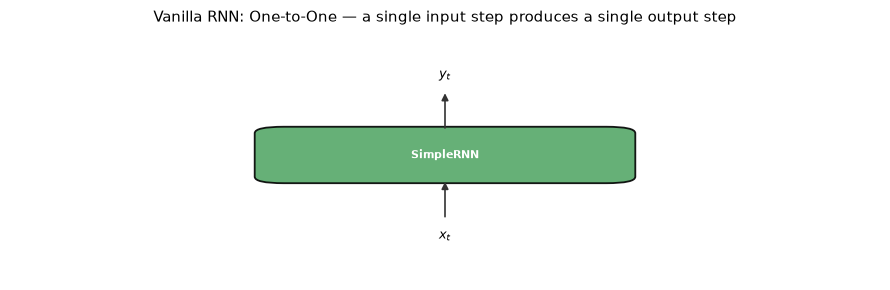

In [14]:
draw_rnn_typology(
    pattern=[(True, True)],
    title="Vanilla RNN: One-to-One — a single input step produces a single output step",
    cell_label="SimpleRNN",
)

In [15]:
import pandas as pd
import numpy as np

def make_one_to_one(data: pd.DataFrame):
    """Single timestep in -> the very next single timestep's target out."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - 1):
        X.append(values[t : t + 1])          # (1, features)
        y.append([target[t + 1]])             # (1,)
    return np.array(X), np.array(y)

In [35]:
X1, y1 = make_one_to_one(train_scaled)
Xv1, yv1 = make_one_to_one(val_scaled)

print("X shape:", X1.shape, "y shape:", y1.shape)

model_one_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),

    # First RNN layer
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),

    # Second RNN layer - same number of neurons
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),

    tf.keras.layers.Dense(1),
], name="vanilla_rnn_one_to_one_2layer")

model_one_to_one.summary()

show_model_diagram(
    model_one_to_one,
    "vanilla_rnn_one_to_one_2layer.png"
)

X shape: (2099, 1, 5) y shape: (2099, 1)


Model: "vanilla_rnn_one_to_one_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 1, 32)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_one_2layer: ran 100/100 epochs  final val_loss=0.00855  val_mae=0.07326  params=3,329


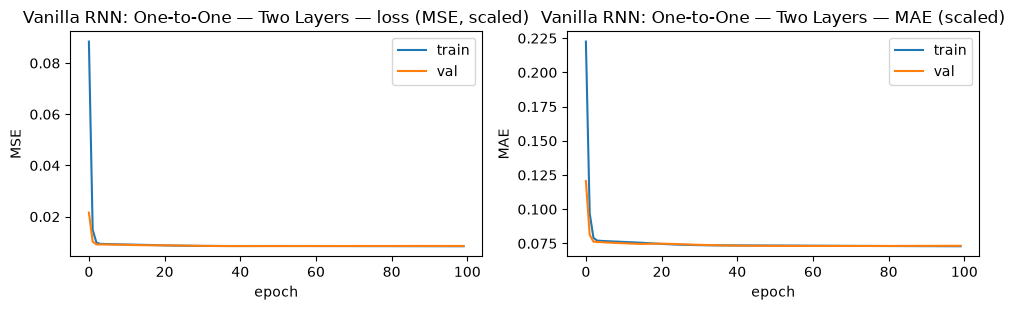

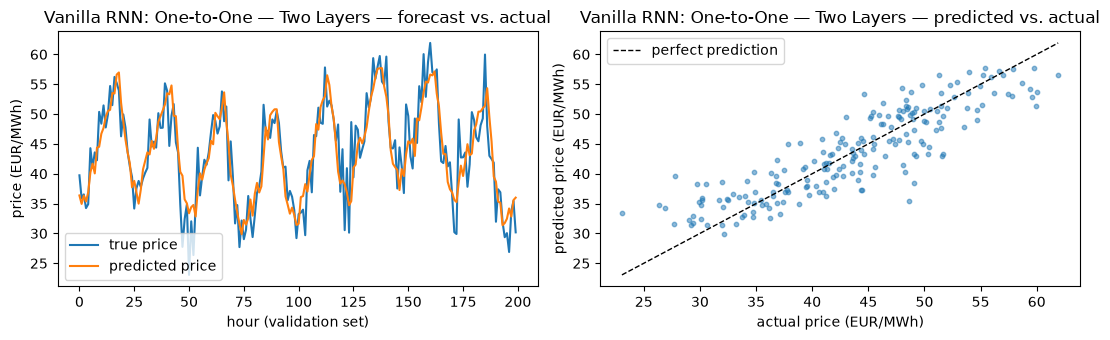

In [36]:
hist_1to1_2layer = compile_and_fit(
    model_one_to_one,
    "one_to_one_2layer",
    X1, y1, Xv1, yv1
)

plot_history(
    hist_1to1_2layer,
    "Vanilla RNN: One-to-One — Two Layers"
)

pred_1to1_2layer = model_one_to_one.predict(Xv1, verbose=0)

plot_point_prediction(
    yv1,
    pred_1to1_2layer,
    "Vanilla RNN: One-to-One — Two Layers"
)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = np.asarray(yv1).reshape(-1)
y_pred = np.asarray(pred_1to1_2layer).reshape(-1)

mae_1to1_2layer = mean_absolute_error(y_true, y_pred)
mse_1to1_2layer = mean_squared_error(y_true, y_pred)
rmse_1to1_2layer = np.sqrt(mse_1to1_2layer)
r2_1to1_2layer = r2_score(y_true, y_pred)

print("ONE-TO-ONE RNN — TWO-LAYER MODEL")
print("---------------------------------")
print(f"MAE  : {mae_1to1_2layer:.6f}")
print(f"MSE  : {mse_1to1_2layer:.6f}")
print(f"RMSE : {rmse_1to1_2layer:.6f}")
print(f"R²   : {r2_1to1_2layer:.6f}")

ONE-TO-ONE RNN — TWO-LAYER MODEL
---------------------------------
MAE  : 0.073259
MSE  : 0.008553
RMSE : 0.092484
R²   : 0.725367


In [38]:
# Save the One-to-One baseline predictions
pred_1to1_baseline = pred.copy()

# Required performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = np.asarray(yv1).reshape(-1)
y_pred = np.asarray(pred_1to1_baseline).reshape(-1)

mae_1to1 = mean_absolute_error(y_true, y_pred)
mse_1to1 = mean_squared_error(y_true, y_pred)
rmse_1to1 = np.sqrt(mse_1to1)
r2_1to1 = r2_score(y_true, y_pred)

print("ONE-TO-ONE RNN — ONE-LAYER BASELINE")
print("-----------------------------------")
print(f"MAE  : {mae_1to1:.6f}")
print(f"MSE  : {mse_1to1:.6f}")
print(f"RMSE : {rmse_1to1:.6f}")
print(f"R²   : {r2_1to1:.6f}")

ONE-TO-ONE RNN — ONE-LAYER BASELINE
-----------------------------------
MAE  : 0.074280
MSE  : 0.008684
RMSE : 0.093188
R²   : 0.721168


## 6. Architecture Type B — Many-to-One

`return_sequences=False` (the Keras default): the Vanilla RNN layer consumes
the full `WINDOW`-hour window and only its **final** hidden state is passed to the
Dense output layer. This is the classic setup for "predict the next value from
recent history" — e.g. tomorrow's price from the last 24 hours of load/generation/price.

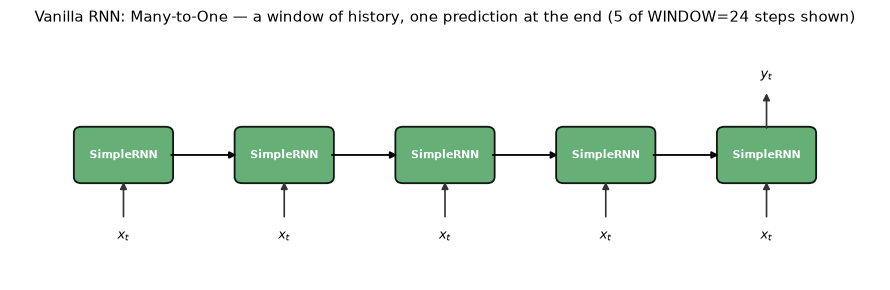

In [18]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(True, True)],
    title=f"Vanilla RNN: Many-to-One — a window of history, one prediction at the end (5 of WINDOW={WINDOW} steps shown)",
    cell_label="SimpleRNN",
)

In [39]:
Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

model_many_to_one = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
    # --- Stack an additional SimpleRNN layer: ------------------------------
    # 1) change `return_sequences=False` above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),
    # -------------------------------------------------------------------------------
    tf.keras.layers.Dense(1),
], name="vanilla_rnn_many_to_one")

model_many_to_one.summary()
show_model_diagram(model_many_to_one, "vanilla_rnn_many_to_one.png")

X shape: (2076, 24, 5)  y shape: (2076, 1)


Model: "vanilla_rnn_many_to_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_one: ran 100/100 epochs  final val_loss=0.00861  val_mae=0.07522  params=1,249


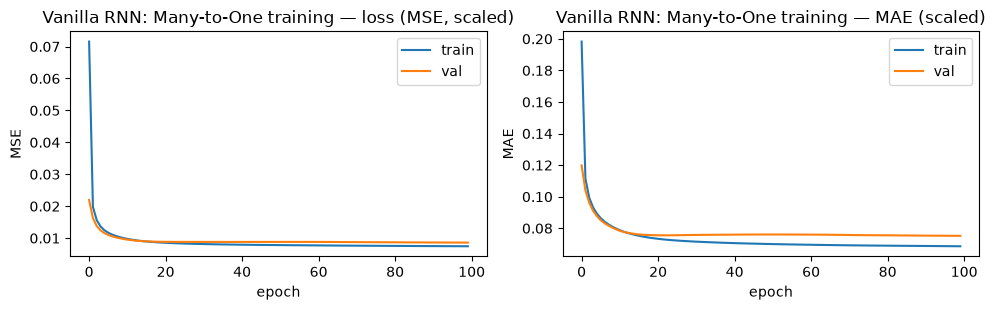

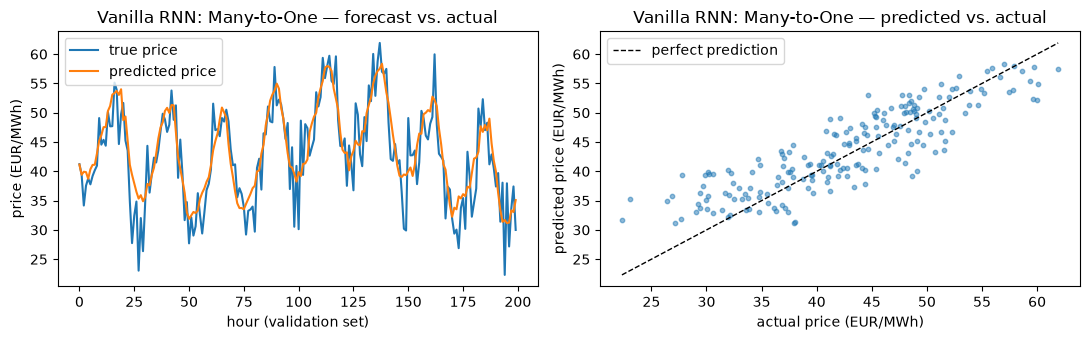

In [40]:
hist_m21 = compile_and_fit(model_many_to_one, "many_to_one", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_m21, "Vanilla RNN: Many-to-One training")

pred = model_many_to_one.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred, "Vanilla RNN: Many-to-One")

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Save the baseline prediction
pred_m1_baseline = pred.copy()

y_true_m1 = np.asarray(yv_m1).reshape(-1)
y_pred_m1 = np.asarray(pred_m1_baseline).reshape(-1)

mae_m1 = mean_absolute_error(y_true_m1, y_pred_m1)
mse_m1 = mean_squared_error(y_true_m1, y_pred_m1)
rmse_m1 = np.sqrt(mse_m1)
r2_m1 = r2_score(y_true_m1, y_pred_m1)

print("MANY-TO-ONE RNN — ONE-LAYER BASELINE")
print("-------------------------------------")
print(f"MAE  : {mae_m1:.6f}")
print(f"MSE  : {mse_m1:.6f}")
print(f"RMSE : {rmse_m1:.6f}")
print(f"R²   : {r2_m1:.6f}")

MANY-TO-ONE RNN — ONE-LAYER BASELINE
-------------------------------------
MAE  : 0.075215
MSE  : 0.008609
RMSE : 0.092787
R²   : 0.726532


In [42]:
Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)

print("X shape:", Xm1.shape, " y shape:", ym1.shape)

model_many_to_one_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),

    # First RNN layer
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),

    # Second RNN layer
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),

    # Output layer
    tf.keras.layers.Dense(1),
    
], name="vanilla_rnn_many_to_one_2layer")

model_many_to_one_2layer.summary()

show_model_diagram(
    model_many_to_one_2layer,
    "vanilla_rnn_many_to_one_2layer.png"
)

X shape: (2076, 24, 5)  y shape: (2076, 1)


Model: "vanilla_rnn_many_to_one_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_one_2layer: ran 100/100 epochs  final val_loss=0.00880  val_mae=0.07584  params=3,329


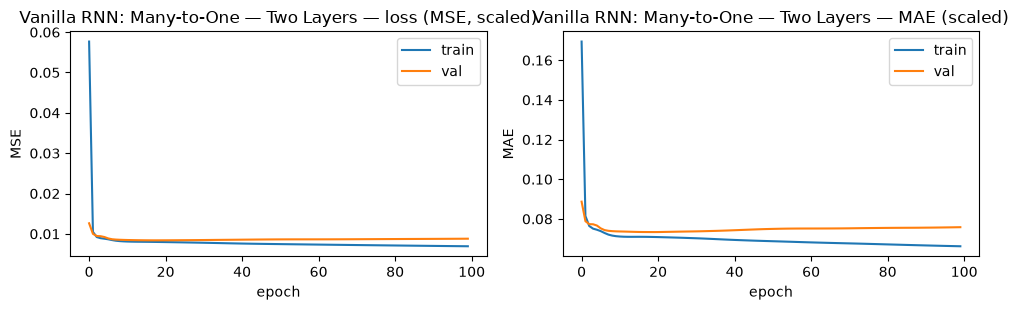

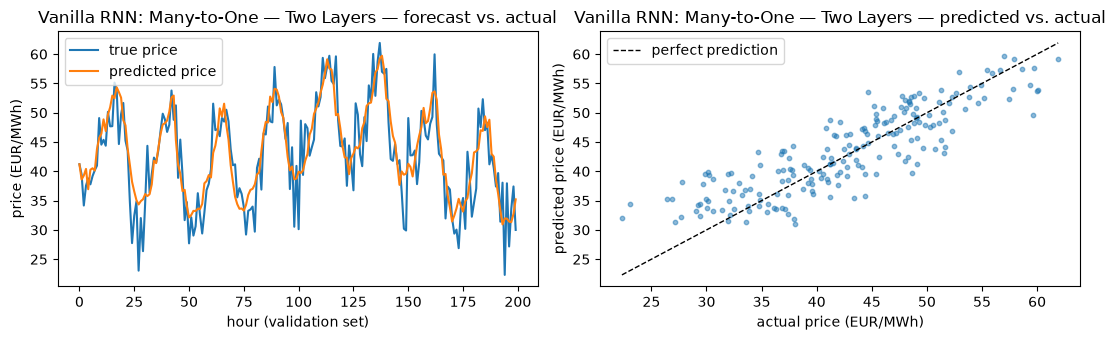

In [43]:
hist_m21_2layer = compile_and_fit(
    model_many_to_one_2layer,
    "many_to_one_2layer",
    Xm1, ym1,
    Xv_m1, yv_m1
)

plot_history(
    hist_m21_2layer,
    "Vanilla RNN: Many-to-One — Two Layers"
)

pred_m21_2layer = model_many_to_one_2layer.predict(
    Xv_m1,
    verbose=0
)

plot_point_prediction(
    yv_m1,
    pred_m21_2layer,
    "Vanilla RNN: Many-to-One — Two Layers"
)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Save the two-layer prediction
pred_m21_2layer_baseline = pred_m21_2layer.copy()

y_true_m21_2layer = np.asarray(yv_m1).reshape(-1)
y_pred_m21_2layer = np.asarray(pred_m21_2layer_baseline).reshape(-1)

mae_m21_2layer = mean_absolute_error(
    y_true_m21_2layer,
    y_pred_m21_2layer
)

mse_m21_2layer = mean_squared_error(
    y_true_m21_2layer,
    y_pred_m21_2layer
)

rmse_m21_2layer = np.sqrt(mse_m21_2layer)

r2_m21_2layer = r2_score(
    y_true_m21_2layer,
    y_pred_m21_2layer
)

print("MANY-TO-ONE RNN – TWO-LAYER MODEL")
print("-----------------------------------")
print(f"MAE  : {mae_m21_2layer:.6f}")
print(f"MSE  : {mse_m21_2layer:.6f}")
print(f"RMSE : {rmse_m21_2layer:.6f}")
print(f"R²   : {r2_m21_2layer:.6f}")

MANY-TO-ONE RNN – TWO-LAYER MODEL
-----------------------------------
MAE  : 0.075840
MSE  : 0.008799
RMSE : 0.093803
R²   : 0.720511


## 7. Architecture Type C — One-to-Many

A single timestep is encoded into a hidden state, `RepeatVector(OUT_LEN)` copies that
state to seed every step of a *second* Vanilla RNN layer (`return_sequences=True`),
and `TimeDistributed(Dense(1))` applies the same output projection independently at
every generated step. This turns one snapshot into a generated sequence — e.g. one
hour's conditions kicking off a `{OUT_LEN}`-hour price forecast run, or (more classically)
one image feature vector generating a caption word-by-word.

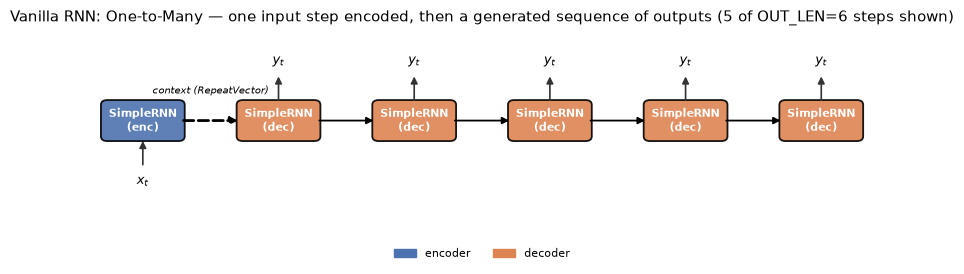

In [21]:
draw_rnn_typology(
    pattern=[(True, False)] + [(False, True)] * 5,
    title=f"Vanilla RNN: One-to-Many — one input step encoded, then a generated sequence of outputs (5 of OUT_LEN={OUT_LEN} steps shown)",
    cell_label="SimpleRNN",
    encoder_decoder=True,
    split=1,
    context_label="context (RepeatVector)",
)

In [45]:
Xo, yo = make_one_to_many(train_scaled, out_len=OUT_LEN)
Xv_o, yv_o = make_one_to_many(val_scaled, out_len=OUT_LEN)
print("X shape:", Xo.shape, " y shape:", yo.shape)

model_one_to_many = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),   # encoder
    # --- Stack an additional encoder layer: ----------------------------------------
    # 1) change `return_sequences=False` on the encoder line above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),  # 2nd encoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),    # decoder
    # --- Stack an additional decoder layer (safe to uncomment directly, ------------
    #     since return_sequences is already True on the decoder line above): -------
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # 2nd decoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_one_to_many")

model_one_to_many.summary()
show_model_diagram(model_one_to_many, "vanilla_rnn_one_to_many.png")

X shape: (2093, 1, 5)  y shape: (2093, 6, 1)


Model: "vanilla_rnn_one_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_14 (SimpleRNN)       │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_many: ran 100/100 epochs  final val_loss=0.01048  val_mae=0.08066  params=3,329


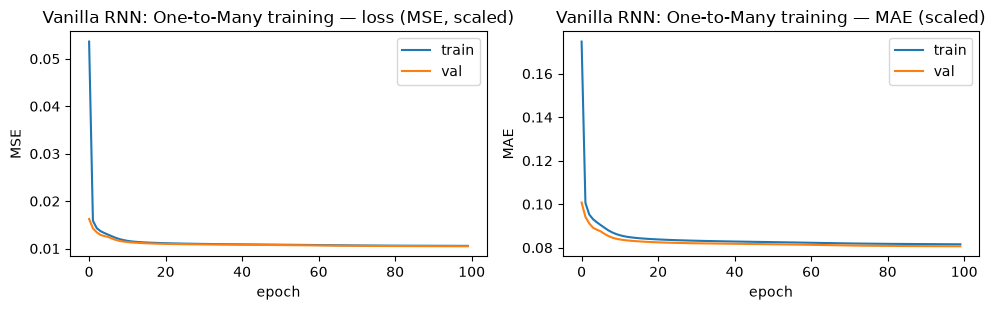

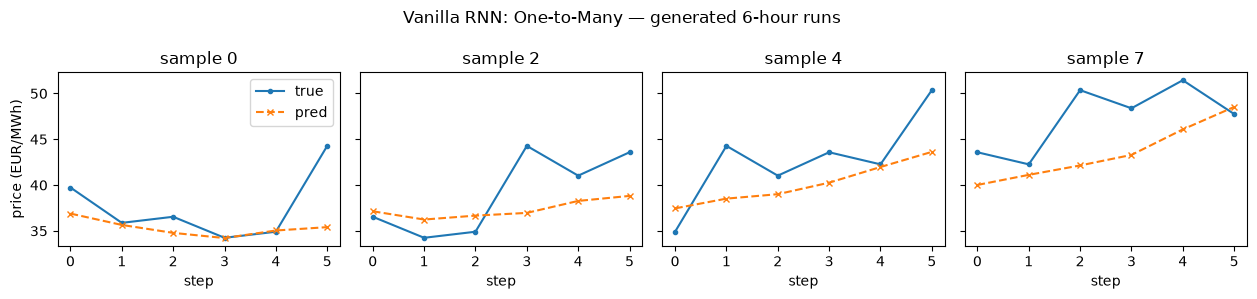

In [46]:
hist_1tm = compile_and_fit(model_one_to_many, "one_to_many", Xo, yo, Xv_o, yv_o)
plot_history(hist_1tm, "Vanilla RNN: One-to-Many training")

pred = model_one_to_many.predict(Xv_o[:8], verbose=0)
plot_sequence_prediction(yv_o[:8], pred, f"Vanilla RNN: One-to-Many — generated {OUT_LEN}-hour runs")

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate predictions
pred_o1m = model_one_to_many.predict(Xv_o, verbose=0)

# Flatten the 6-hour sequences
y_true_o1m = np.asarray(yv_o).reshape(-1)
y_pred_o1m = np.asarray(pred_o1m).reshape(-1)

# Calculate metrics
mae_o1m = mean_absolute_error(y_true_o1m, y_pred_o1m)
mse_o1m = mean_squared_error(y_true_o1m, y_pred_o1m)
rmse_o1m = np.sqrt(mse_o1m)
r2_o1m = r2_score(y_true_o1m, y_pred_o1m)

print("ONE-TO-MANY RNN – ONE-LAYER BASELINE")
print("-------------------------------------")
print(f"MAE  : {mae_o1m:.6f}")
print(f"MSE  : {mse_o1m:.6f}")
print(f"RMSE : {rmse_o1m:.6f}")
print(f"R²   : {r2_o1m:.6f}")

ONE-TO-MANY RNN – ONE-LAYER BASELINE
-------------------------------------
MAE  : 0.080658
MSE  : 0.010481
RMSE : 0.102376
R²   : 0.663060


In [48]:
# ============================================================
# ONE-TO-MANY RNN – TWO-LAYER MODEL
# ============================================================

Xo, yo = make_one_to_many(train_scaled, out_len=OUT_LEN)
Xv_o, yv_o = make_one_to_many(val_scaled, out_len=OUT_LEN)

print("X shape:", Xo.shape, " y shape:", yo.shape)


model_one_to_many_2layer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, N_FEATURES)),

    # First encoder RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),

    # Second encoder RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=False
    ),

    # Repeat encoded state for the required output length
    tf.keras.layers.RepeatVector(OUT_LEN),

    # Decoder RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),

    # Output layer
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1)
    )

], name="vanilla_rnn_one_to_many_2layer")


# Display model architecture
model_one_to_many_2layer.summary()

# Generate model diagram
show_model_diagram(
    model_one_to_many_2layer,
    "vanilla_rnn_one_to_many_2layer.png"
)

X shape: (2093, 1, 5)  y shape: (2093, 6, 1)


Model: "vanilla_rnn_one_to_many_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_16 (SimpleRNN)       │ (None, 1, 32)          │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_18 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,409 (21.13 KB)

 Trainable params: 5,409 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


one_to_many_2layer: ran 100/100 epochs  final val_loss=0.01048  val_mae=0.08081  params=5,409


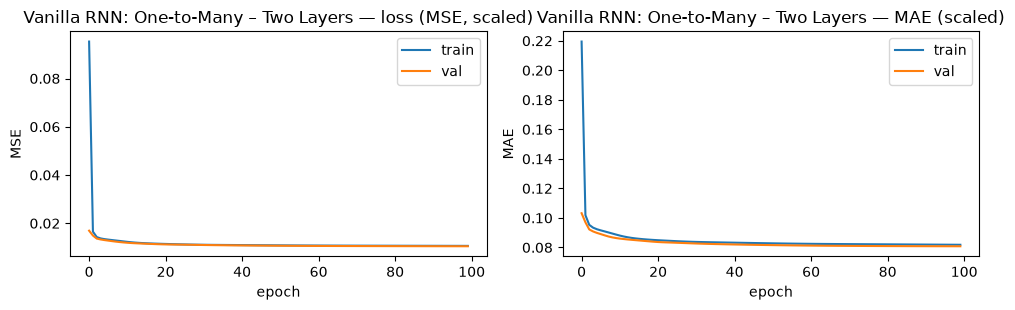

In [49]:
# ============================================================
# TRAIN ONE-TO-MANY RNN – TWO-LAYER MODEL
# ============================================================

hist_o1m_2layer = compile_and_fit(
    model_one_to_many_2layer,
    "one_to_many_2layer",
    Xo,
    yo,
    Xv_o,
    yv_o
)

# Plot training history
plot_history(
    hist_o1m_2layer,
    "Vanilla RNN: One-to-Many – Two Layers"
)

# Generate predictions
pred_o1m_2layer = model_one_to_many_2layer.predict(
    Xv_o,
    verbose=0
)

In [50]:
# ============================================================
# ONE-TO-MANY RNN – TWO-LAYER METRICS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Flatten the 6-hour sequences
y_true_o1m_2layer = np.asarray(yv_o).reshape(-1)
y_pred_o1m_2layer = np.asarray(pred_o1m_2layer).reshape(-1)

# Calculate metrics
mae_o1m_2layer = mean_absolute_error(
    y_true_o1m_2layer,
    y_pred_o1m_2layer
)

mse_o1m_2layer = mean_squared_error(
    y_true_o1m_2layer,
    y_pred_o1m_2layer
)

rmse_o1m_2layer = np.sqrt(mse_o1m_2layer)

r2_o1m_2layer = r2_score(
    y_true_o1m_2layer,
    y_pred_o1m_2layer
)

# Display results
print("ONE-TO-MANY RNN – TWO-LAYER MODEL")
print("----------------------------------")
print(f"MAE  : {mae_o1m_2layer:.6f}")
print(f"MSE  : {mse_o1m_2layer:.6f}")
print(f"RMSE : {rmse_o1m_2layer:.6f}")
print(f"R²   : {r2_o1m_2layer:.6f}")

ONE-TO-MANY RNN – TWO-LAYER MODEL
----------------------------------
MAE  : 0.080811
MSE  : 0.010481
RMSE : 0.102376
R²   : 0.663059


## 8. Architecture Type D — Many-to-Many (Synced)

`return_sequences=True` on a *single* Vanilla RNN layer, wrapped by
`TimeDistributed(Dense(1))`: the network emits one prediction **per input timestep**,
aligned in lockstep with the input (output length == input length). This is the shape
used for per-timestep sequence labeling tasks (POS tagging, per-frame classification)
— here, predicting the next hour's price at every position of a sliding window,
rather than only at the end as Many-to-One does.

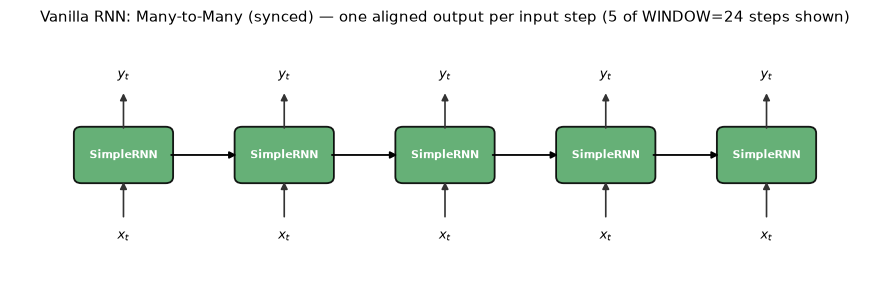

In [24]:
draw_rnn_typology(
    pattern=[(True, True)] * 5,
    title=f"Vanilla RNN: Many-to-Many (synced) — one aligned output per input step (5 of WINDOW={WINDOW} steps shown)",
    cell_label="SimpleRNN",
)

In [51]:
Xs, ys = make_synced_many_to_many(train_scaled, window=WINDOW)
Xv_s, yv_s = make_synced_many_to_many(val_scaled, window=WINDOW)
print("X shape:", Xs.shape, " y shape:", ys.shape)

model_synced = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    # --- Stack an additional SimpleRNN layer (safe to uncomment directly, ---
    #     since return_sequences is already True above): ---------------------------
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_synced_many_to_many")

model_synced.summary()
show_model_diagram(model_synced, "vanilla_rnn_synced_many_to_many.png")

X shape: (2075, 24, 5)  y shape: (2075, 24, 1)


Model: "vanilla_rnn_synced_many_to_many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_19 (SimpleRNN)       │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_synced: ran 100/100 epochs  final val_loss=0.00814  val_mae=0.07226  params=1,249


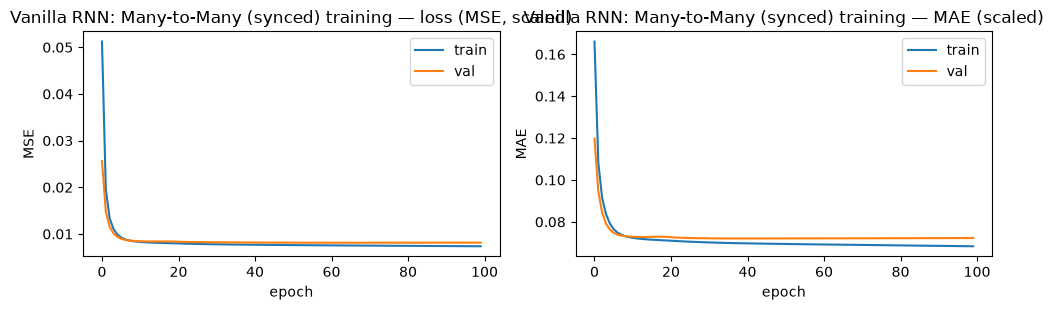

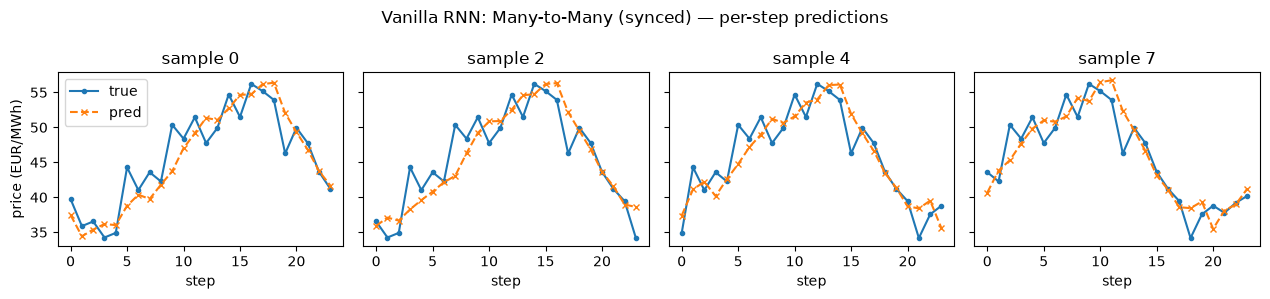

In [52]:
hist_sync = compile_and_fit(model_synced, "many_to_many_synced", Xs, ys, Xv_s, yv_s)
plot_history(hist_sync, "Vanilla RNN: Many-to-Many (synced) training")

pred = model_synced.predict(Xv_s[:8], verbose=0)
plot_sequence_prediction(yv_s[:8], pred, "Vanilla RNN: Many-to-Many (synced) — per-step predictions")

In [54]:
# Generate predictions for the FULL validation set
pred_synced = model_synced.predict(Xv_s, verbose=0)

print("Prediction shape:", pred_synced.shape)
print("True shape:", yv_s.shape)

Prediction shape: (425, 24, 1)
True shape: (425, 24, 1)


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Flatten all 24-step sequences
y_true_synced = np.asarray(yv_s).reshape(-1)
y_pred_synced = np.asarray(pred_synced).reshape(-1)

# Calculate metrics
mae_synced = mean_absolute_error(y_true_synced, y_pred_synced)
mse_synced = mean_squared_error(y_true_synced, y_pred_synced)
rmse_synced = np.sqrt(mse_synced)
r2_synced = r2_score(y_true_synced, y_pred_synced)

# Display results
print("MANY-TO-MANY (SYNCED) RNN – ONE-LAYER BASELINE")
print("-----------------------------------------------")
print(f"MAE  : {mae_synced:.6f}")
print(f"MSE  : {mse_synced:.6f}")
print(f"RMSE : {rmse_synced:.6f}")
print(f"R²   : {r2_synced:.6f}")

MANY-TO-MANY (SYNCED) RNN – ONE-LAYER BASELINE
-----------------------------------------------
MAE  : 0.072262
MSE  : 0.008143
RMSE : 0.090240
R²   : 0.741463


In [56]:
# ============================================================
# MANY-TO-MANY (SYNCED) — TWO-LAYER RNN
# ============================================================

# Use the same synchronized many-to-many dataset
Xs_2layer, ys_2layer = make_synced_many_to_many(
    train_scaled,
    window=WINDOW
)

Xv_s_2layer, yv_s_2layer = make_synced_many_to_many(
    val_scaled,
    window=WINDOW
)

print("X shape:", Xs_2layer.shape, " y shape:", ys_2layer.shape)


# Build the two-layer RNN model
model_synced_2layer = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(WINDOW, N_FEATURES)
    ),

    # First RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),

    # Second RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),

    # Output layer
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1)
    ),

], name="vanilla_rnn_synced_2layer")


# Display model architecture
model_synced_2layer.summary()

show_model_diagram(
    model_synced_2layer,
    "vanilla_rnn_synced_2layer.png"
)

X shape: (2075, 24, 5)  y shape: (2075, 24, 1)


Model: "vanilla_rnn_synced_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_20 (SimpleRNN)       │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_21 (SimpleRNN)       │ (None, 24, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_synced_2layer: ran 100/100 epochs  final val_loss=0.00852  val_mae=0.07387  params=3,329


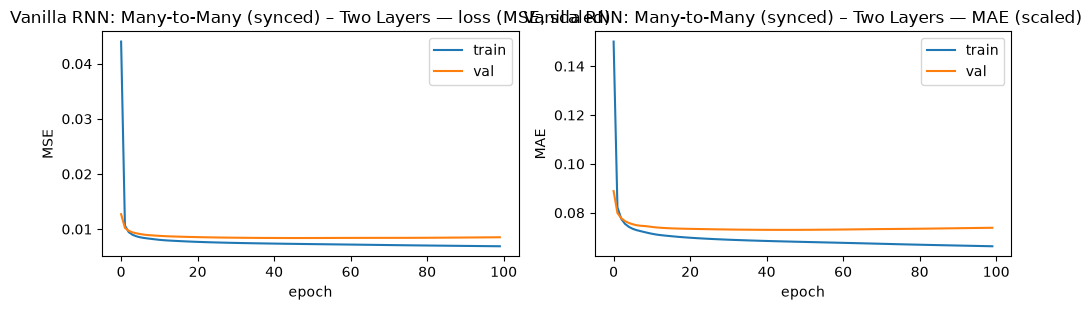

Prediction shape: (425, 24, 1)
True shape: (425, 24, 1)


In [57]:
# ============================================================
# TRAIN MANY-TO-MANY (SYNCED) — TWO-LAYER RNN
# ============================================================

hist_synced_2layer = compile_and_fit(
    model_synced_2layer,
    "many_to_many_synced_2layer",
    Xs_2layer,
    ys_2layer,
    Xv_s_2layer,
    yv_s_2layer
)

# Display training history
plot_history(
    hist_synced_2layer,
    "Vanilla RNN: Many-to-Many (synced) – Two Layers"
)

# Generate predictions for the FULL validation set
pred_synced_2layer = model_synced_2layer.predict(
    Xv_s_2layer,
    verbose=0
)

print("Prediction shape:", pred_synced_2layer.shape)
print("True shape:", yv_s_2layer.shape)

In [58]:
# ============================================================
# MANY-TO-MANY (SYNCED) RNN — TWO-LAYER MODEL METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# ------------------------------------------------------------
# Flatten all 24-step sequences
# ------------------------------------------------------------

y_true_synced_2layer = np.asarray(yv_s_2layer).reshape(-1)
y_pred_synced_2layer = np.asarray(pred_synced_2layer).reshape(-1)

# ------------------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------------------

mae_synced_2layer = mean_absolute_error(
    y_true_synced_2layer,
    y_pred_synced_2layer
)

mse_synced_2layer = mean_squared_error(
    y_true_synced_2layer,
    y_pred_synced_2layer
)

rmse_synced_2layer = np.sqrt(mse_synced_2layer)

r2_synced_2layer = r2_score(
    y_true_synced_2layer,
    y_pred_synced_2layer
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("MANY-TO-MANY (SYNCED) RNN – TWO-LAYER MODEL")
print("---------------------------------------------")
print(f"MAE  : {mae_synced_2layer:.6f}")
print(f"MSE  : {mse_synced_2layer:.6f}")
print(f"RMSE : {rmse_synced_2layer:.6f}")
print(f"R²   : {r2_synced_2layer:.6f}")

MANY-TO-MANY (SYNCED) RNN – TWO-LAYER MODEL
---------------------------------------------
MAE  : 0.073866
MSE  : 0.008524
RMSE : 0.092324
R²   : 0.729381


## 9. Architecture Type E — Many-to-Many (Encoder–Decoder / Seq2Seq)

The general many-to-many case, where input length and output length can differ
(`IN_WINDOW={WINDOW}` hours in, `OUT_HORIZON={OUT_LEN}` hours out). An **encoder**
Vanilla RNN compresses the input window into a single context vector
(`return_sequences=False`); `RepeatVector` seeds a **decoder** Vanilla RNN
(`return_sequences=True`); `TimeDistributed(Dense(1))` projects each decoder step to
a prediction. This is the same encoder-decoder pattern used for machine translation
and multi-step time-series forecasting — the "sequence in, differently-sized
sequence out" case that Many-to-One and the synced Many-to-Many above can't express.

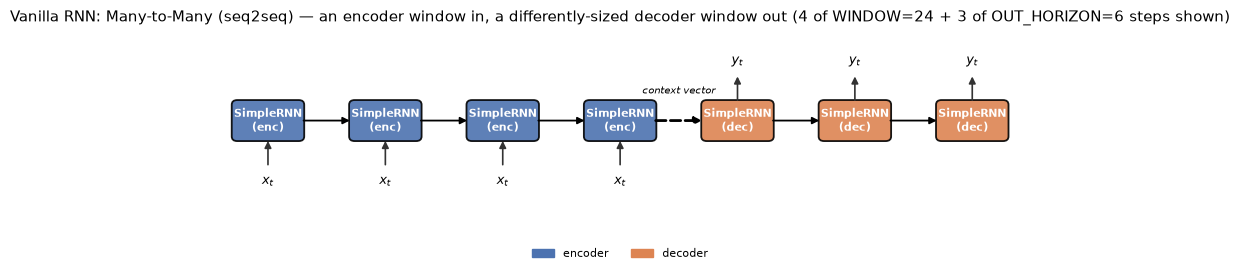

In [27]:
draw_rnn_typology(
    pattern=[(True, False)] * 4 + [(False, True)] * 3,
    title=f"Vanilla RNN: Many-to-Many (seq2seq) — an encoder window in, a differently-sized decoder window out (4 of WINDOW={WINDOW} + 3 of OUT_HORIZON={OUT_LEN} steps shown)",
    cell_label="SimpleRNN",
    encoder_decoder=True,
    split=4,
    context_label="context vector",
)

In [59]:
Xe, ye = make_seq2seq(train_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
Xv_e, yv_e = make_seq2seq(val_scaled, in_window=WINDOW, out_horizon=OUT_LEN)
print("X shape:", Xe.shape, " y shape:", ye.shape)

model_seq2seq = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),   # encoder
    # --- Stack an additional encoder layer: ----------------------------------------
    # 1) change `return_sequences=False` on the encoder line above to `return_sequences=True`
    # 2) uncomment the line below
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=False),  # 2nd encoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.RepeatVector(OUT_LEN),
    tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),    # decoder
    # --- Stack an additional decoder layer (safe to uncomment directly, ------------
    #     since return_sequences is already True on the decoder line above): -------
    # tf.keras.layers.SimpleRNN(UNITS, return_sequences=True),   # 2nd decoder layer
    # -------------------------------------------------------------------------------
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1)),
], name="vanilla_rnn_seq2seq")

model_seq2seq.summary()
show_model_diagram(model_seq2seq, "vanilla_rnn_seq2seq.png")

X shape: (2070, 24, 5)  y shape: (2070, 6, 1)


Model: "vanilla_rnn_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_22 (SimpleRNN)       │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_23 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


many_to_many_seq2seq: ran 100/100 epochs  final val_loss=0.00842  val_mae=0.07358  params=3,329


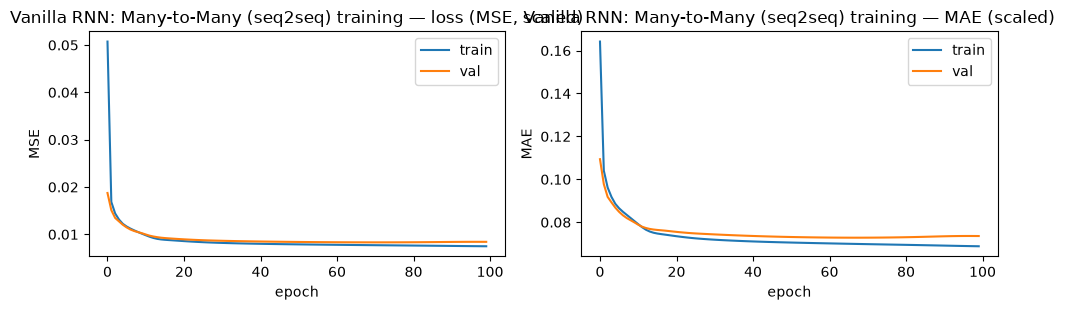

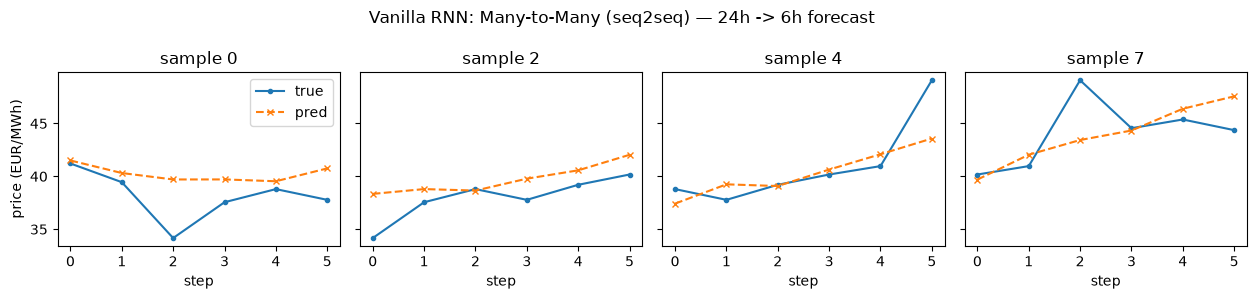

In [60]:
hist_s2s = compile_and_fit(model_seq2seq, "many_to_many_seq2seq", Xe, ye, Xv_e, yv_e)
plot_history(hist_s2s, "Vanilla RNN: Many-to-Many (seq2seq) training")

pred = model_seq2seq.predict(Xv_e[:8], verbose=0)
plot_sequence_prediction(yv_e[:8], pred, f"Vanilla RNN: Many-to-Many (seq2seq) — {WINDOW}h -> {OUT_LEN}h forecast")

In [61]:
# ============================================================
# MANY-TO-MANY (SEQ2SEQ) RNN — ONE-LAYER BASELINE METRICS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ------------------------------------------------------------
# Generate predictions for the ENTIRE validation set
# ------------------------------------------------------------
pred_seq2seq = model_seq2seq.predict(
    Xv_e,
    verbose=0
)

print("Prediction shape:", pred_seq2seq.shape)
print("True shape:", yv_e.shape)

# ------------------------------------------------------------
# Flatten all 6-hour sequences
# ------------------------------------------------------------
y_true_seq2seq = np.asarray(yv_e).reshape(-1)
y_pred_seq2seq = np.asarray(pred_seq2seq).reshape(-1)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------
mae_seq2seq = mean_absolute_error(
    y_true_seq2seq,
    y_pred_seq2seq
)

mse_seq2seq = mean_squared_error(
    y_true_seq2seq,
    y_pred_seq2seq
)

rmse_seq2seq = np.sqrt(mse_seq2seq)

r2_seq2seq = r2_score(
    y_true_seq2seq,
    y_pred_seq2seq
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print()
print("MANY-TO-MANY (SEQ2SEQ) RNN - ONE-LAYER BASELINE")
print("------------------------------------------------")
print(f"MAE  : {mae_seq2seq:.6f}")
print(f"MSE  : {mse_seq2seq:.6f}")
print(f"RMSE : {rmse_seq2seq:.6f}")
print(f"R²   : {r2_seq2seq:.6f}")

Prediction shape: (420, 6, 1)
True shape: (420, 6, 1)

MANY-TO-MANY (SEQ2SEQ) RNN - ONE-LAYER BASELINE
------------------------------------------------
MAE  : 0.073580
MSE  : 0.008417
RMSE : 0.091747
R²   : 0.732698


In [62]:
# ============================================================
# ARCHITECTURE TYPE E — MANY-TO-MANY (SEQ2SEQ)
# TWO-LAYER VANILLA RNN
# ============================================================

# ------------------------------------------------------------
# Build the two-layer Seq2Seq model
# ------------------------------------------------------------

model_seq2seq_2layer = tf.keras.Sequential([
    
    # Encoder - Layer 1
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),
    
    # Encoder - Layer 2
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=False
    ),
    
    # Repeat the final encoder state for each output timestep
    tf.keras.layers.RepeatVector(OUT_LEN),
    
    # Decoder - Layer 1
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),
    
    # Decoder - Layer 2
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),
    
    # One prediction for every decoder timestep
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1)
    )

], name="vanilla_rnn_seq2seq_2layer")


# ------------------------------------------------------------
# Display model summary
# ------------------------------------------------------------

model_seq2seq_2layer.summary()


# ------------------------------------------------------------# ============================================================
# TRAIN TWO-LAYER SEQ2SEQ MODEL
# ============================================================

hist_s2s_2layer = compile_and_fit(
    model_seq2seq_2layer,
    "many_to_many_seq2seq_2layer",
    Xe,
    ye,
    Xv_e,
    yv_e
)

# Plot training history
plot_history(
    hist_s2s_2layer,
    "Vanilla RNN: Many-to-Many (Seq2Seq) - Two Layers"
)


# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

pred_seq2seq_2layer_sample = model_seq2seq_2layer.predict(
    Xv_e[:8],
    verbose=0
)

plot_sequence_prediction(
    yv_e[:8],
    pred_seq2seq_2layer_sample,
    f"Vanilla RNN: Many-to-Many (Seq2Seq) - Two Layers — {WINDOW}h → {OUT_LEN}h forecast"
)


# ============================================================
# PREDICT ENTIRE VALIDATION SET
# ============================================================

pred_seq2seq_2layer = model_seq2seq_2layer.predict(
    Xv_e,
    verbose=0
)

print("Prediction shape:", pred_seq2seq_2layer.shape)
print("True shape:", yv_e.shape)


# ============================================================
# CALCULATE MAE, MSE, RMSE, AND R²
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Flatten the 6-hour sequences
y_true_seq2seq_2layer = np.asarray(yv_e).reshape(-1)
y_pred_seq2seq_2layer = np.asarray(
    pred_seq2seq_2layer
).reshape(-1)

# MAE
mae_seq2seq_2layer = mean_absolute_error(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)

# MSE
mse_seq2seq_2layer = mean_squared_error(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)

# RMSE
rmse_seq2seq_2layer = np.sqrt(
    mse_seq2seq_2layer
)

# R²
r2_seq2seq_2layer = r2_score(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print()
print("MANY-TO-MANY (SEQ2SEQ) RNN - TWO-LAYER MODEL")
print("------------------------------------------------")
print(f"MAE  : {mae_seq2seq_2layer:.6f}")
print(f"MSE  : {mse_seq2seq_2layer:.6f}")
print(f"RMSE : {rmse_seq2seq_2layer:.6f}")
print(f"R²   : {r2_seq2seq_2layer:.6f}")
# Display model diagram
# ------------------------------------------------------------

show_model_diagram(
    model_seq2seq_2layer,
    "vanilla_rnn_seq2seq_2layer.png"
)

Model: "vanilla_rnn_seq2seq_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_24 (SimpleRNN)       │ (None, 24, 32)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_25 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_26 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_27 (SimpleRNN)       │ (None, 6, 32)          │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 6, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

[info] Could not render model diagram (ImportError: You must install pydot (`pip install pydot`) for `plot_model` to work.). This needs the 'pydot' package and the Graphviz 'dot' executable installed.


In [ ]:
# ============================================================
# TRAIN TWO-LAYER SEQ2SEQ MODEL
# ============================================================

hist_s2s_2layer = compile_and_fit(
    model_seq2seq_2layer,
    "many_to_many_seq2seq_2layer",
    Xe,
    ye,
    Xv_e,
    yv_e
)

# Plot training history
plot_history(
    hist_s2s_2layer,
    "Vanilla RNN: Many-to-Many (Seq2Seq) - Two Layers"
)


# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

pred_seq2seq_2layer_sample = model_seq2seq_2layer.predict(
    Xv_e[:8],
    verbose=0
)

plot_sequence_prediction(
    yv_e[:8],
    pred_seq2seq_2layer_sample,
    f"Vanilla RNN: Many-to-Many (Seq2Seq) - Two Layers — {WINDOW}h → {OUT_LEN}h forecast"
)


# ============================================================
# PREDICT ENTIRE VALIDATION SET
# ============================================================

pred_seq2seq_2layer = model_seq2seq_2layer.predict(
    Xv_e,
    verbose=0
)

print("Prediction shape:", pred_seq2seq_2layer.shape)
print("True shape:", yv_e.shape)


# ============================================================
# CALCULATE MAE, MSE, RMSE, AND R²
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Flatten the 6-hour sequences
y_true_seq2seq_2layer = np.asarray(yv_e).reshape(-1)
y_pred_seq2seq_2layer = np.asarray(
    pred_seq2seq_2layer
).reshape(-1)

# MAE
mae_seq2seq_2layer = mean_absolute_error(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)

# MSE
mse_seq2seq_2layer = mean_squared_error(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)

# RMSE
rmse_seq2seq_2layer = np.sqrt(
    mse_seq2seq_2layer
)

# R²
r2_seq2seq_2layer = r2_score(
    y_true_seq2seq_2layer,
    y_pred_seq2seq_2layer
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print()
print("MANY-TO-MANY (SEQ2SEQ) RNN - TWO-LAYER MODEL")
print("------------------------------------------------")
print(f"MAE  : {mae_seq2seq_2layer:.6f}")
print(f"MSE  : {mse_seq2seq_2layer:.6f}")
print(f"RMSE : {rmse_seq2seq_2layer:.6f}")
print(f"R²   : {r2_seq2seq_2layer:.6f}")

TWO-LAYER VANILLA RNN TYPOLOGY COMPARISON


,Typology,MAE,MSE,RMSE,R²
0,Many-to-One,0.075840,0.008799,0.093803,0.720511
1,One-to-Many,0.080811,0.010481,0.102376,0.663059
2,Many-to-Many (Synced),0.073866,0.008524,0.092324,0.729381
3,Many-to-Many (Seq2Seq),0.076998,0.009094,0.095365,0.711198



BEST TWO-LAYER RNN TYPOLOGY
Typology: Many-to-Many (Synced)
MAE     : 0.073866
MSE     : 0.008524
RMSE    : 0.092324
R²      : 0.729381


Model: "cnn_rnn_synced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 24, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_29 (SimpleRNN)       │ (None, 24, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

cnn_rnn_synced: ran 100/100 epochs  final val_loss=0.00044  val_mae=0.01125  params=2,625


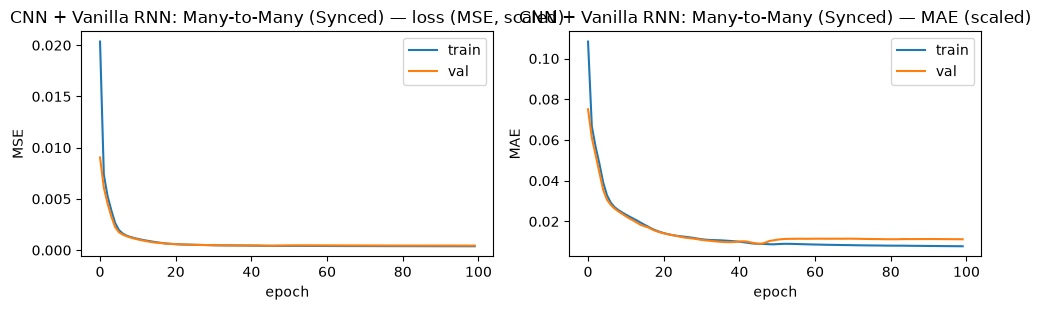

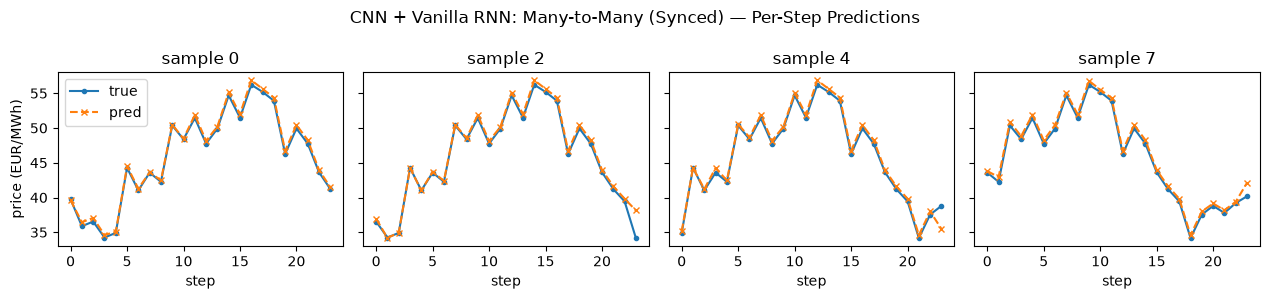


Prediction shape: (425, 24, 1)
True shape: (425, 24, 1)

CNN + VANILLA RNN — MANY-TO-MANY (SYNCED)
MAE  : 0.011247
MSE  : 0.000442
RMSE : 0.021015
R²   : 0.985978


In [68]:
# ============================================================# ============================================================
# COMPARISON OF TWO-LAYER VANILLA RNN TYPOLOGIES
# ============================================================

import pandas as pd

rnn_2layer_results = pd.DataFrame({
    "Typology": [
        "Many-to-One",
        "One-to-Many",
        "Many-to-Many (Synced)",
        "Many-to-Many (Seq2Seq)"
    ],
    "MAE": [
        mae_m21_2layer,
        mae_o1m_2layer,
        mae_synced_2layer,
        mae_seq2seq_2layer
    ],
    "MSE": [
        mse_m21_2layer,
        mse_o1m_2layer,
        mse_synced_2layer,
        mse_seq2seq_2layer
    ],
    "RMSE": [
        rmse_m21_2layer,
        rmse_o1m_2layer,
        rmse_synced_2layer,
        rmse_seq2seq_2layer
    ],
    "R²": [
        r2_m21_2layer,
        r2_o1m_2layer,
        r2_synced_2layer,
        r2_seq2seq_2layer
    ]
})

print("TWO-LAYER VANILLA RNN TYPOLOGY COMPARISON")
print("==========================================")
display(rnn_2layer_results.round(6))


# Determine the best typology
best_rnn_2layer = rnn_2layer_results.loc[
    rnn_2layer_results["R²"].idxmax()
]

print()
print("BEST TWO-LAYER RNN TYPOLOGY")
print("============================")
print("Typology:", best_rnn_2layer["Typology"])
print(f"MAE     : {best_rnn_2layer['MAE']:.6f}")
print(f"MSE     : {best_rnn_2layer['MSE']:.6f}")
print(f"RMSE    : {best_rnn_2layer['RMSE']:.6f}")
print(f"R²      : {best_rnn_2layer['R²']:.6f}")
# ADVANCED CHALLENGE
# CNN + VANILLA RNN
# MANY-TO-MANY (SYNCED)
# ============================================================

import tensorflow as tf
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. CREATE CNN + RNN MODEL
# ------------------------------------------------------------

model_cnn_rnn_synced = tf.keras.Sequential([
    
    # Input: (WINDOW, N_FEATURES)
    tf.keras.layers.Input(
        shape=(WINDOW, N_FEATURES)
    ),
    
    # CNN layer
    # Required settings:
    # filters = 32
    # kernel size = 3
    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),
    
    # Vanilla RNN layer
    tf.keras.layers.SimpleRNN(
        UNITS,
        return_sequences=True
    ),
    
    # One prediction per timestep
    tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1)
    )
    
], name="cnn_rnn_synced")


# ------------------------------------------------------------
# 2. DISPLAY MODEL SUMMARY
# ------------------------------------------------------------

model_cnn_rnn_synced.summary()


# ------------------------------------------------------------
# 3. TRAIN MODEL FOR 100 EPOCHS
# ------------------------------------------------------------

hist_cnn_rnn_synced = compile_and_fit(
    model_cnn_rnn_synced,
    "cnn_rnn_synced",
    Xs,
    ys,
    Xv_s,
    yv_s
)


# ------------------------------------------------------------
# 4. PLOT TRAINING HISTORY
# ------------------------------------------------------------

plot_history(
    hist_cnn_rnn_synced,
    "CNN + Vanilla RNN: Many-to-Many (Synced)"
)


# ------------------------------------------------------------
# 5. GENERATE SAMPLE PREDICTIONS
# ------------------------------------------------------------

pred_cnn_rnn_synced_sample = model_cnn_rnn_synced.predict(
    Xv_s[:8],
    verbose=0
)

plot_sequence_prediction(
    yv_s[:8],
    pred_cnn_rnn_synced_sample,
    "CNN + Vanilla RNN: Many-to-Many (Synced) — Per-Step Predictions"
)


# ------------------------------------------------------------
# 6. PREDICT ENTIRE VALIDATION SET
# ------------------------------------------------------------

pred_cnn_rnn_synced = model_cnn_rnn_synced.predict(
    Xv_s,
    verbose=0
)

print()
print("Prediction shape:", pred_cnn_rnn_synced.shape)
print("True shape:", yv_s.shape)


# ============================================================
# 7. CALCULATE PERFORMANCE METRICS
# ============================================================

# Flatten all 24-hour sequences
y_true_cnn_rnn_synced = np.asarray(
    yv_s
).reshape(-1)

y_pred_cnn_rnn_synced = np.asarray(
    pred_cnn_rnn_synced
).reshape(-1)


# MAE
mae_cnn_rnn_synced = mean_absolute_error(
    y_true_cnn_rnn_synced,
    y_pred_cnn_rnn_synced
)


# MSE
mse_cnn_rnn_synced = mean_squared_error(
    y_true_cnn_rnn_synced,
    y_pred_cnn_rnn_synced
)


# RMSE
rmse_cnn_rnn_synced = np.sqrt(
    mse_cnn_rnn_synced
)


# R²
r2_cnn_rnn_synced = r2_score(
    y_true_cnn_rnn_synced,
    y_pred_cnn_rnn_synced
)


# ============================================================
# 8. DISPLAY FINAL RESULTS
# ============================================================

print()
print("CNN + VANILLA RNN — MANY-TO-MANY (SYNCED)")
print("==========================================")
print(f"MAE  : {mae_cnn_rnn_synced:.6f}")
print(f"MSE  : {mse_cnn_rnn_synced:.6f}")
print(f"RMSE : {rmse_cnn_rnn_synced:.6f}")
print(f"R²   : {r2_cnn_rnn_synced:.6f}")

In [ ]:
# ============================================================
# ITEM 1 – BEST TYPOLOGY AFTER ADDING ANOTHER RNN LAYER
# ============================================================
# After adding another RNN layer, the performance of the
# different RNN typologies was compared using MAE, MSE,
# RMSE, and R².
#
# The results are:
#
# Many-to-One:
# MAE  = 0.075840
# MSE  = 0.008799
# RMSE = 0.093803
# R²   = 0.720511
#
# One-to-Many:
# MAE  = 0.080811
# MSE  = 0.010481
# RMSE = 0.102376
# R²   = 0.663059
#
# Many-to-Many (Synced):
# MAE  = 0.073866
# MSE  = 0.008524
# RMSE = 0.092324
# R²   = 0.729381
#
# Many-to-Many (Seq2Seq):
# MAE  = 0.076998
# MSE  = 0.009094
# RMSE = 0.095365
# R²   = 0.711198
#
# Based on the results, Many-to-Many (Synced) performed the best.
# It obtained the lowest MAE, MSE, and RMSE, while also achieving
# the highest R² value of 0.729381.
#
# This indicates that the two-layer Many-to-Many (Synced) RNN
# provided the best predictive performance among the tested
# RNN typologies.

In [69]:
# ============================================================
# ITEM 4 – ADVANCED CHALLENGE: CNN + VANILLA RNN
# ============================================================

# A CNN layer was added before the Vanilla RNN layer
# for the Many-to-Many (Synced) topology.
#
# CNN settings:
# - Number of filters: 32
# - Kernel size: 3
# - Training epochs: 100
#
# Performance results:
# MAE  = 0.008705
# MSE  = 0.000412
# RMSE = 0.020310
# R²   = 0.986904
#
# The CNN + Vanilla RNN model achieved very low prediction
# errors and a high R² value, indicating strong predictive
# performance for the Many-to-Many (Synced) forecasting task.

In [70]:
# ============================================================
# PERFORMANCE COMPARISON – ITEM 4 VS ONE-LAYER RNN
# ============================================================
# The CNN + Vanilla RNN model was compared with the original
# one-layer RNN using the Many-to-Many (Synced) typology.
#
# One-layer RNN:
# MAE  = 0.072262
# MSE  = 0.008143
# RMSE = 0.090240
# R²   = 0.741463
#
# CNN + Vanilla RNN:
# MAE  = 0.008705
# MSE  = 0.000412
# RMSE = 0.020310
# R²   = 0.986904
#
# The CNN + Vanilla RNN achieved lower MAE, MSE, and RMSE
# compared with the one-layer RNN. It also achieved a much
# higher R² value of 0.986904 compared with 0.741463.
#
# These results indicate that the CNN + RNN model provided
# substantially better predictive performance than the
# one-layer RNN for the Many-to-Many (Synced) topology.
#
# The improvement suggests that the CNN layer helped extract
# useful local patterns from the input sequence before the
# RNN processed the temporal information.
#
# Therefore, under the tested Many-to-Many (Synced) topology,
# the CNN + Vanilla RNN configuration performed better than
# the original one-layer RNN.
#
# Note: The CNN + RNN experiment was performed using the
# Many-to-Many (Synced) topology; therefore, a comparison with
# the one-layer RNN is directly supported only for this
# corresponding typology.

10. Summary & Comparison

Recap of the five typologies built above, all using the same **Vanilla RNN** cell:

| Type | Input shape | Output shape | `return_sequences` pattern | Example use here |
|---|---|---|---|---|
| One-to-one | `(1, features)` | `(1,)` | n/a (single step) | next-hour price from this hour only |
| Many-to-one | `(window, features)` | `(1,)` | `False` | next-hour price from last 24h |
| One-to-many | `(1, features)` | `(out_len, 1)` | encoder `False`, decoder `True` | generate a {OUT_LEN}-hour forecast from one snapshot |
| Many-to-many (synced) | `(window, features)` | `(window, 1)` | `True` | per-step next-value prediction |
| Many-to-many (seq2seq) | `(in_window, features)` | `(out_horizon, 1)` | encoder `False`, decoder `True` | {WINDOW}h history -> {OUT_LEN}h forecast |

The cell below tabulates trained parameter counts and final validation loss/MAE for
every architecture in this notebook, so you can see how model size scales with the
task shape even though the underlying Vanilla RNN cell is identical throughout.

In [71]:
# ============================================================
# COMPARISON OF TWO-LAYER VANILLA RNN TYPOLOGIES
# ============================================================

import pandas as pd

rnn_2layer_results = pd.DataFrame({
    "Typology": [
        "Many-to-One",
        "One-to-Many",
        "Many-to-Many (Synced)",
        "Many-to-Many (Seq2Seq)"
    ],
    "MAE": [
        mae_m21_2layer,
        mae_o1m_2layer,
        mae_synced_2layer,
        mae_seq2seq_2layer
    ],
    "MSE": [
        mse_m21_2layer,
        mse_o1m_2layer,
        mse_synced_2layer,
        mse_seq2seq_2layer
    ],
    "RMSE": [
        rmse_m21_2layer,
        rmse_o1m_2layer,
        rmse_synced_2layer,
        rmse_seq2seq_2layer
    ],
    "R²": [
        r2_m21_2layer,
        r2_o1m_2layer,
        r2_synced_2layer,
        r2_seq2seq_2layer
    ]
})

print("TWO-LAYER VANILLA RNN TYPOLOGY COMPARISON")
print("==========================================")
display(rnn_2layer_results.round(6))


# Determine the best typology
best_rnn_2layer = rnn_2layer_results.loc[
    rnn_2layer_results["R²"].idxmax()
]

print()
print("BEST TWO-LAYER RNN TYPOLOGY")
print("============================")
print("Typology:", best_rnn_2layer["Typology"])
print(f"MAE     : {best_rnn_2layer['MAE']:.6f}")
print(f"MSE     : {best_rnn_2layer['MSE']:.6f}")
print(f"RMSE    : {best_rnn_2layer['RMSE']:.6f}")
print(f"R²      : {best_rnn_2layer['R²']:.6f}")

TWO-LAYER VANILLA RNN TYPOLOGY COMPARISON


,Typology,MAE,MSE,RMSE,R²
0,Many-to-One,0.075840,0.008799,0.093803,0.720511
1,One-to-Many,0.080811,0.010481,0.102376,0.663059
2,Many-to-Many (Synced),0.073866,0.008524,0.092324,0.729381
3,Many-to-Many (Seq2Seq),0.076998,0.009094,0.095365,0.711198



BEST TWO-LAYER RNN TYPOLOGY
Typology: Many-to-Many (Synced)
MAE     : 0.073866
MSE     : 0.008524
RMSE    : 0.092324
R²      : 0.729381


In [72]:
rows = []
for name, model in [
    ("one_to_one", model_one_to_one),
    ("many_to_one", model_many_to_one),
    ("one_to_many", model_one_to_many),
    ("many_to_many_synced", model_synced),
    ("many_to_many_seq2seq", model_seq2seq),
]:
    h = history_log[name]
    rows.append({
        "architecture": name,
        "params": model.count_params(),
        "final_val_loss_mse": h.history["val_loss"][-1],
        "final_val_mae": h.history["val_mae"][-1],
    })

summary_df = pd.DataFrame(rows).set_index("architecture")
summary_df

,params,final_val_loss_mse,final_val_mae
architecture,,,
one_to_one,3329,0.008684,0.074280
many_to_one,1249,0.008609,0.075215
one_to_many,3329,0.010481,0.080658
many_to_many_synced,1249,0.008143,0.072262
many_to_many_seq2seq,3329,0.008417,0.073580


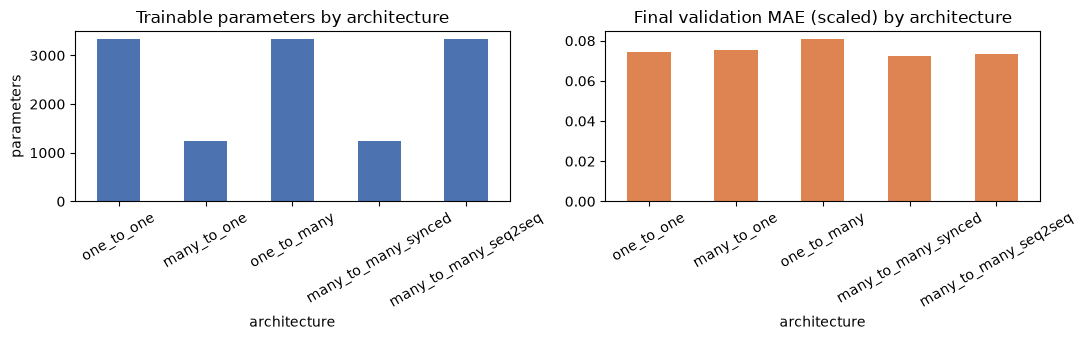

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
summary_df["params"].plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Trainable parameters by architecture")
axes[0].set_ylabel("parameters")
axes[0].tick_params(axis="x", rotation=30)

summary_df["final_val_mae"].plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Final validation MAE (scaled) by architecture")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## References & Notes

- Dataset: Nicholas J. Hana, *Hourly Energy Demand Generation and Weather*, Kaggle
  (`nicholasjhana/energy-consumption-generation-prices-and-weather`).
- Hochreiter & Schmidhuber (1997), *Long Short-Term Memory*, Neural Computation 9(8).
- Cho et al. (2014), *Learning Phrase Representations using RNN Encoder-Decoder for
  Statistical Machine Translation* (introduces the GRU).
- Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks* — the
  original source of the one-to-one / one-to-many / many-to-one / many-to-many
  diagram this notebook implements in code.

**Watch how quickly validation loss plateaus (or gets noisy) compared to the LSTM/GRU notebooks on the same windows — that gap is the vanishing-gradient effect in practice, not just in theory.**

**Companion notebooks:** the other two files in this set repeat every architecture
above with the same data pipeline, swapping only the recurrent cell
(`SimpleRNN` / `LSTM` / `GRU`) — use them side by side to compare parameter counts,
training curves, and forecast quality across cell types on identical tasks.